<a href="https://colab.research.google.com/github/practicalClerk/ICU-Patient-Risk-Stratification/blob/main/ICU_Risk_Stratisfaction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###*Project Information
Every day, doctors in ICUs (Intensive Care Units) face two critical questions the moment a patient is admitted:

Is this patient at risk of dying? — So they can prioritize care immediately.
How long will this patient stay in the ICU? — So the hospital can plan beds, staff, and resources.

Right now, these decisions rely heavily on doctor experience and intuition. The goal of this project is to use Machine Learning to answer both questions automatically using data collected in the first 24 hours of a patient's ICU admission — before the situation gets critical.*

##Importing Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Load Dataset

In [2]:
df = pd.read_csv("training_v2.csv")

print("Shape:", df.shape)
df.head()

Shape: (10421, 186)


,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma


##Basic Information

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10421 entries, 0 to 10420
Columns: 186 entries, encounter_id to apache_2_bodysystem
dtypes: float64(170), int64(8), object(8)
memory usage: 14.8+ MB


,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,height,icu_id,pre_icu_los_days,...,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis
count,10421.000000,10421.000000,10421.000000,10421.000000,9933.000000,8657.000000,10421.000000,10244.000000,10421.000000,10421.000000,...,9856.000000,9856.000000,10342.000000,10342.000000,10342.000000,10342.000000,10342.000000,10342.000000,10342.000000,10342.000000
mean,66295.612609,65839.990596,103.951636,0.064773,62.397564,29.782426,0.224163,169.925146,107.681508,0.622537,...,0.064522,0.033725,0.000483,0.017792,0.225295,0.013634,0.045639,0.007445,0.005705,0.026301
std,37817.390919,37437.138895,31.531847,0.246137,16.596879,8.376535,0.417050,10.696126,22.068355,2.117318,...,0.235011,0.199737,0.021984,0.132199,0.417797,0.115970,0.208711,0.085969,0.075319,0.160035
min,12.000000,6.000000,4.000000,0.000000,16.000000,14.844926,0.000000,137.200000,82.000000,-4.647917,...,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34014.000000,33538.000000,83.000000,0.000000,53.000000,23.985891,0.000000,162.600000,92.000000,0.002083,...,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,66743.000000,66045.000000,118.000000,0.000000,64.000000,28.197546,0.000000,170.200000,100.000000,0.011806,...,0.040000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,99180.000000,98113.000000,118.000000,0.000000,75.000000,33.720476,0.000000,177.800000,114.000000,0.171528,...,0.100000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,131045.000000,131040.000000,198.000000,1.000000,89.000000,67.814990,1.000000,195.590000,252.000000,49.523611,...,0.980000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##Co-relation Analysis

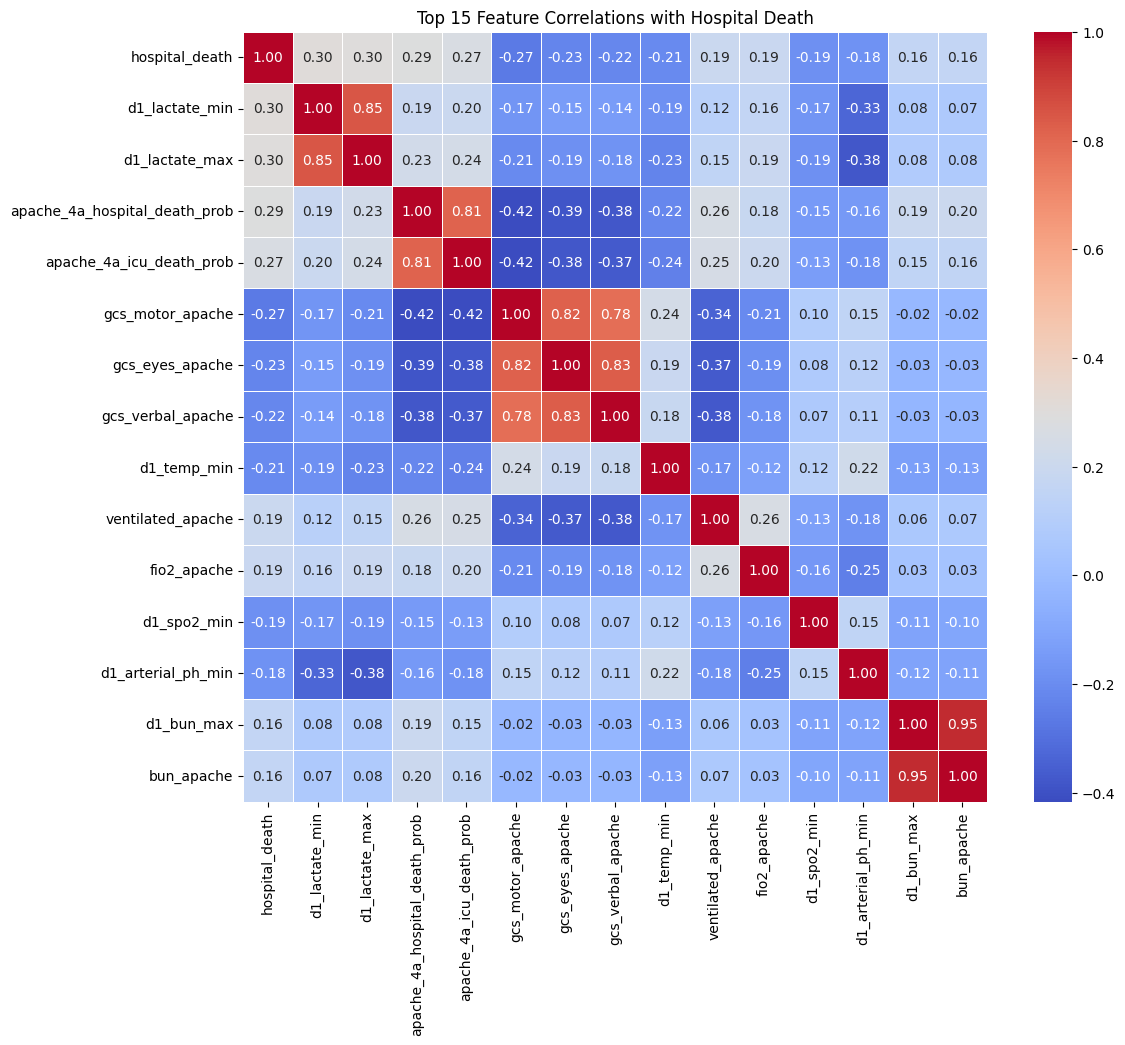

In [31]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

top_corr_features = corr_matrix['hospital_death'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.loc[top_corr_features, top_corr_features],
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Top 15 Feature Correlations with Hospital Death")
plt.show()

##Clean Column Names

In [4]:
df.columns = df.columns.str.strip().str.lower()

##Handle Missing Values

In [5]:
# Fill numeric columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Check again
df.isnull().sum().sum()

np.int64(1770)

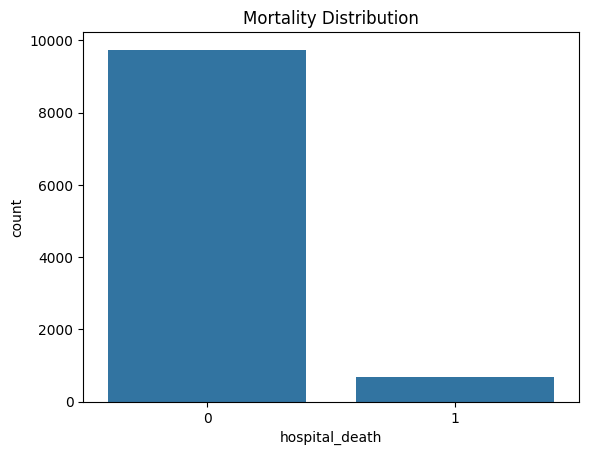

In [6]:
sns.countplot(x='hospital_death', data=df)
plt.title("Mortality Distribution")
plt.show()

##Target Variables

In [11]:
# @title
# Mortality (classification)
y_clf = df['hospital_death']

y_reg = df['pre_icu_los_days'] # Using 'pre_icu_los_days' as a placeholder for Length of stay


##Feature Selection

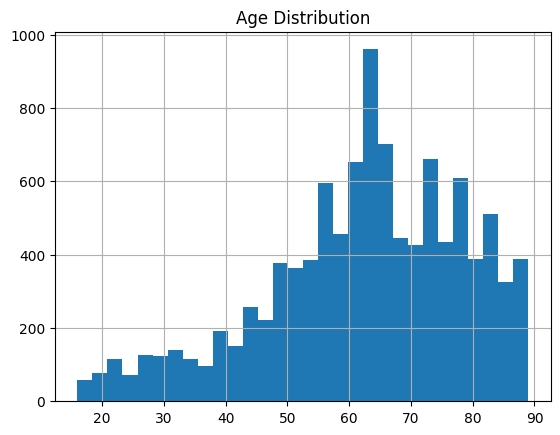

In [12]:
df['age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()

In [13]:
X = df.drop(['hospital_death', 'pre_icu_los_days'], axis=1)

##Encoding

In [14]:
X = pd.get_dummies(X, drop_first=True)

##Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42)

_, _, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

##Classification Model

##Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_clf_train)

y_pred_clf = clf.predict(X_test)
lr_prob = clf.predict_proba(X_test)[:, 1]

##Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_clf_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

##XG Boost

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_clf_train)

xgb_prob = xgb.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:58:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


##Evaluation(Classification)

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_clf_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_clf_test, rf_pred))

Accuracy: 0.9477218225419665
ROC-AUC: 0.5907021598591897


##Evaluation (Regression)

In [22]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
print("RMSE:", rmse)

RMSE: 2.1640001284707986


##ROC-AUC Scores

In [26]:
from sklearn.metrics import roc_auc_score

print("Logistic Regression:", roc_auc_score(y_clf_test, lr_prob))
print("Random Forest:", roc_auc_score(y_clf_test, rf_prob))
print("XGBoost:", roc_auc_score(y_clf_test, xgb_prob))

Logistic Regression: 0.8694337977661167
Random Forest: 0.88840864601668
XGBoost: 0.904023621917718


##ROC Curve

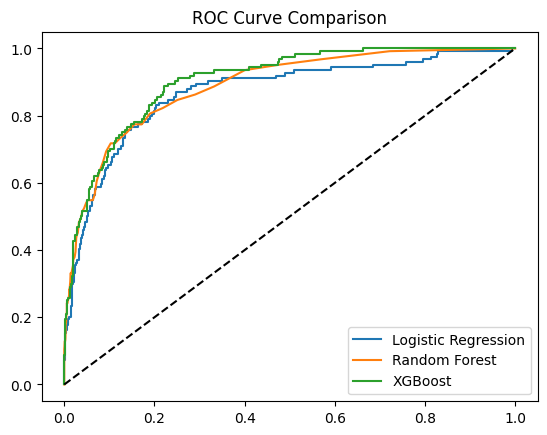

In [28]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_clf_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_clf_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_clf_test, xgb_prob)

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

##Feature Importance

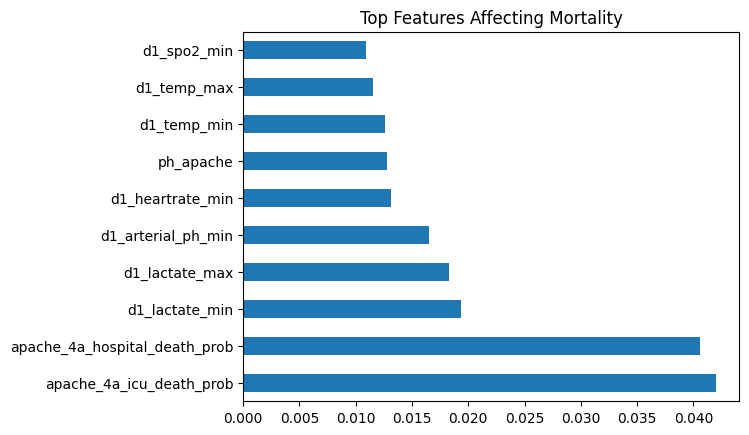

In [29]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Top Features Affecting Mortality")
plt.show()